In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import time

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [4]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
]
)

In [5]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
]
)

In [6]:

data_dir = './train'


In [7]:
full_dataset = datasets.ImageFolder(root = data_dir, transform= test_transform)
classes = full_dataset.classes
classes

['Circle', 'Rectangle', 'Triangle']

In [8]:
#  split 80/20
train_size = int(0.8 * len(full_dataset))

test_size = len(full_dataset) - train_size

train_size, test_size


(800, 200)

In [9]:
trainset, testset = random_split(full_dataset, [train_size, test_size])

In [10]:
testset.dataset = datasets.ImageFolder(root = data_dir, transform = test_transform)

In [11]:
trainloader = DataLoader(trainset, batch_size = 32, shuffle = True, num_workers=2)
testloader = DataLoader(testset, batch_size=32, shuffle= False, num_workers=2)

In [12]:
class ShapeNet(nn.Module):
    def __init__(self, num_classes=5, freeze_backbone=False):
        super().__init__()
        self.backbone = models.mobilenet_v3_small(weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requieres_grad = False
        
        in_features = self.backbone.classifier[-1].in_features
        
        self.backbone.classifier[-1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)
        

In [13]:
model = ShapeNet(num_classes=len(classes), freeze_backbone= False)
model.to(device)

ShapeNet(
  (backbone): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [15]:
train_losses, test_accs = [], []
for epoch in range(10):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(trainloader))

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        test_accs.append(100 * correct / total)
        print(f'Epoch [{epoch + 1}/10], loss: {train_losses[-1]:.3f}, Test Acc: {test_accs[-1]:.2f}%')

Epoch [1/10], loss: 0.131, Test Acc: 85.00%
Epoch [2/10], loss: 0.006, Test Acc: 90.50%
Epoch [3/10], loss: 0.011, Test Acc: 97.00%
Epoch [4/10], loss: 0.001, Test Acc: 99.50%
Epoch [5/10], loss: 0.000, Test Acc: 99.50%
Epoch [6/10], loss: 0.000, Test Acc: 100.00%
Epoch [7/10], loss: 0.000, Test Acc: 100.00%
Epoch [8/10], loss: 0.000, Test Acc: 100.00%
Epoch [9/10], loss: 0.000, Test Acc: 100.00%
Epoch [10/10], loss: 0.000, Test Acc: 100.00%


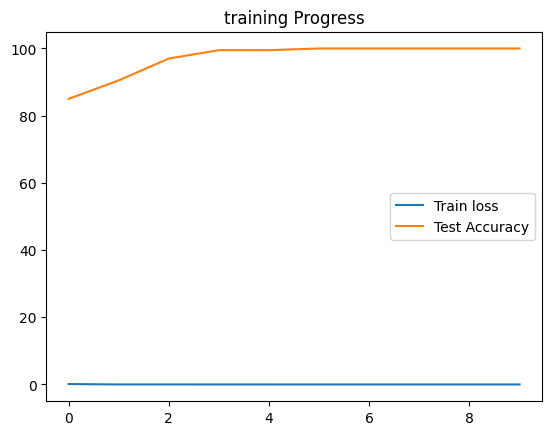

In [16]:
plt.plot(train_losses, label = 'Train loss')
plt.plot(test_accs, label= 'Test Accuracy')
plt.legend()
plt.title('training Progress')
plt.show()

In [17]:

import os

image_folder = './test_single'
files = [f for f in os.listdir(image_folder)]
files[:5]

['test_0.png', 'test_1.png', 'test_10.png', 'test_100.png', 'test_101.png']

In [18]:
batch = []
for fname in files:
    img = Image.open(f'{image_folder}/{fname}').convert('RGB')
    batch.append(test_transform(img).numpy())


In [19]:
batch = torch.stack([torch.tensor(f) for f in batch])

In [20]:
model.eval()
with torch.no_grad():
    outputs = model(batch.to(device))
    preds = torch.argmax(outputs, dim=1)
    pred = preds.cpu().numpy()

In [21]:
preds

tensor([2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 1, 0, 2, 0, 1, 0, 1, 1, 2, 2, 1, 0, 1, 2,
        2, 2, 0, 0, 0, 0, 0, 2, 1, 0, 1, 2, 1, 1, 1, 2, 0, 2, 1, 0, 2, 1, 1, 0,
        0, 1, 2, 1, 1, 0, 2, 1, 1, 1, 2, 1, 2, 0, 2, 1, 1, 0, 2, 1, 2, 0, 1, 2,
        2, 2, 2, 1, 1, 0, 0, 1, 2, 1, 2, 2, 2, 2, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
        1, 0, 1, 0, 2, 1, 2, 1, 2, 1, 1, 2, 0, 1, 0, 2, 2, 0, 2, 0, 1, 2, 1, 1,
        2, 0, 2, 0, 0, 0, 2, 1, 2, 1, 2, 2, 2, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
        2, 1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 0, 1, 2, 0, 1, 2, 2, 0, 1, 0, 1, 2,
        2, 2, 0, 2, 1, 0, 2, 2, 2, 1, 0, 0, 1, 2, 2, 1, 2, 0, 1, 0, 2, 2, 0, 0,
        0, 0, 2, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 0, 1, 0, 2, 1, 2, 0, 0, 2, 0, 2,
        2, 1, 2, 1, 1, 0, 1, 1, 1, 1, 0, 2, 0, 1, 2, 2, 0, 0, 1, 2, 0, 2, 2, 2,
        1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 2,
        1, 2, 1, 2, 1, 0, 2, 2, 2, 2, 2, 0, 0, 0, 1, 0, 0, 0, 2, 2, 1, 0, 0, 2,
        2, 2, 1, 1, 0, 2, 0, 1, 2, 1, 2,

In [22]:
label_map = {0: 'Circle', 1: 'Rectangle', 2: 'Triangle'}

In [23]:
import pandas as pd
pred_df = pd.DataFrame(preds)
pred_df.head()

,0
0,2
1,2
2,2
3,1
4,1


In [24]:
pred_df = pred_df[0].map(label_map)
pred_df.head()

0     Triangle
1     Triangle
2     Triangle
3    Rectangle
4    Rectangle
Name: 0, dtype: object

In [25]:
# header=False — otherwise pandas writes column name "0" as the first line
pred_df.to_csv('predicted.csv', header=False, index=False)